Dataset Shape: (9564, 26)
Cleaned Dataset Shape: (7585, 25)

========== CLASSIFICATION ==========
F1 Score: 0.8936970837253058
ROC AUC: 0.980674855861145


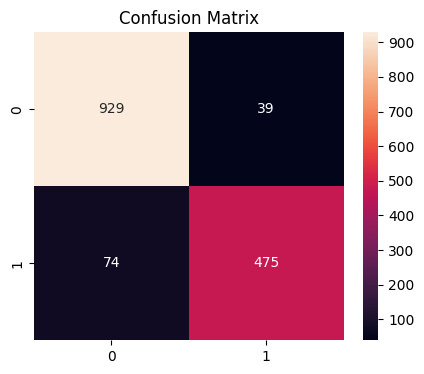


========== REGRESSION ==========
MAE: 64.12673363556199
RMSE: 1773.9975829900184


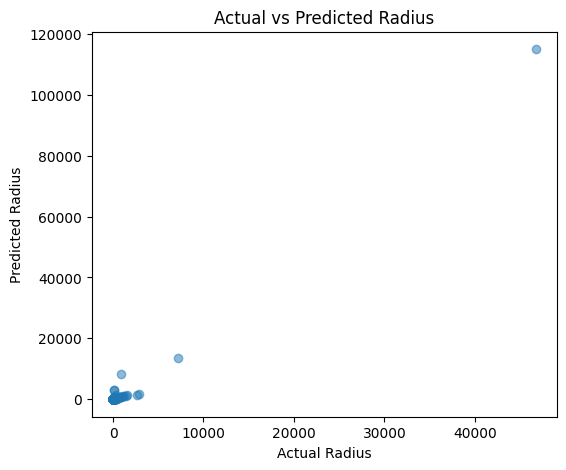


Top 10 Important Features
koi_ror             0.100791
feh_err2            0.095995
koi_model_snr       0.079641
koi_period          0.072989
feh_err1            0.070426
teff_err1           0.069357
teff_err2           0.060329
koi_num_transits    0.056527
koi_impact          0.055056
koi_depth           0.053492
dtype: float64


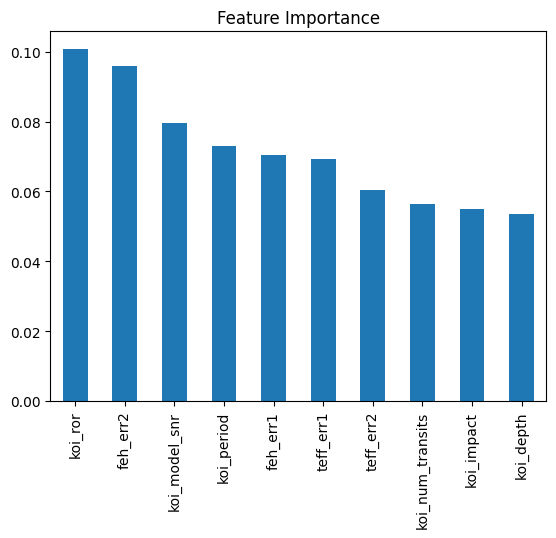


Models saved successfully.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import joblib

# ===============================
# LOAD DATA
# ===============================
df = pd.read_csv("supernova_dataset.csv")

print("Dataset Shape:", df.shape)

# ===============================
# REMOVE USELESS COLUMNS
# ===============================
drop_cols = [
    "kepid",
    "kepoi_name",
    "koi_pdisposition"
]

df = df.drop(columns=drop_cols, errors="ignore")

# ===============================
# REMOVE CANDIDATE CLASS
# ===============================
df = df[df["koi_disposition"] != "CANDIDATE"]

# ===============================
# MAP TARGET LABELS
# ===============================
df["koi_disposition"] = df["koi_disposition"].map({
    "CONFIRMED":1,
    "FALSE POSITIVE":0
})

# ===============================
# HANDLE MISSING VALUES
# ===============================
df = df.fillna(df.median(numeric_only=True))

print("Cleaned Dataset Shape:", df.shape)

# ===============================
# CLASSIFICATION DATA
# ===============================
X_class = df.drop(["koi_disposition","koi_prad"], axis=1, errors="ignore")
y_class = df["koi_disposition"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# ===============================
# CLASSIFICATION PIPELINE
# ===============================
clf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=400,
        max_depth=15,
        min_samples_split=4,
        random_state=42,
        n_jobs=-1
    ))
])

clf_pipeline.fit(X_train_c, y_train_c)

pred = clf_pipeline.predict(X_test_c)
prob = clf_pipeline.predict_proba(X_test_c)[:,1]

print("\n========== CLASSIFICATION ==========")
print("F1 Score:", f1_score(y_test_c, pred))
print("ROC AUC:", roc_auc_score(y_test_c, prob))

cm = confusion_matrix(y_test_c, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# REGRESSION DATA
# ===============================
# use only confirmed planets for radius prediction
df_reg = df[df["koi_disposition"] == 1]

# remove rows where radius missing
df_reg = df_reg.dropna(subset=["koi_prad"])

X_reg = df_reg.drop(["koi_prad","koi_disposition"], axis=1)
y_reg = df_reg["koi_prad"]

# ===============================
# REGRESSION PIPELINE
# ===============================
reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        n_estimators=400,
        max_depth=18,
        min_samples_split=4,
        random_state=42,
        n_jobs=-1
    ))
])

reg_pipeline.fit(X_train_r, y_train_r)

pred_r = reg_pipeline.predict(X_test_r)

mae = mean_absolute_error(y_test_r, pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, pred_r))

print("\n========== REGRESSION ==========")
print("MAE:", mae)
print("RMSE:", rmse)

plt.figure(figsize=(6,5))
plt.scatter(y_test_r, pred_r, alpha=0.5)
plt.xlabel("Actual Radius")
plt.ylabel("Predicted Radius")
plt.title("Actual vs Predicted Radius")
plt.show()

# ===============================
# FEATURE IMPORTANCE
# ===============================
model = clf_pipeline.named_steps["model"]

importances = pd.Series(
    model.feature_importances_,
    index=X_class.columns
).sort_values(ascending=False)

print("\nTop 10 Important Features")
print(importances.head(10))

importances.head(10).plot(kind="bar")
plt.title("Feature Importance")
plt.show()

# ===============================
# SAVE MODELS
# ===============================
joblib.dump(clf_pipeline, "classification_model.pkl")
joblib.dump(reg_pipeline, "radius_model.pkl")

print("\nModels saved successfully.")